<a href="https://www.kaggle.com/code/nicapotato/laptop-battery-analysis?scriptVersionId=340389879" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Guided Numeric Exploration — Laptop Battery Health
_Synthetic degradation patterns: age, cycles, thermals, and usage vs remaining health_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [dharmendrapandit12/laptop-battery-health-dataset](https://www.kaggle.com/datasets/dharmendrapandit12/laptop-battery-health-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distributions](#Univariate)** <br>
**4. [Identity Check: Health vs Capacity Ratio](#Identity)** <br>
**5. [Degradation Drivers](#Drivers)** <br>
**6. [Usage Intensity and Thermals](#Usage)** <br>
**7. [Association Without Leakage](#Association)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **synthetic** 1,200-row laptop battery table (MIT) built for regression and predictive-maintenance practice. Features cover battery age, daily hours, gaming flag, design capacity, cycle count, CPU/GPU usage, power, temperature, full-charge capacity, and target `Battery Health` (%).

**Critical leakage note:** health is nearly identical to `Full Charge Capacity / Design Capacity × 100`. Any model that includes FCC is mostly reconstructing that ratio. Exploratory importances below exclude FCC on purpose.

Interpretations are about associations in the generator, not advice for real laptop fleets.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "battery_health_dataset.csv"
KAGGLE_SLUG = "dharmendrapandit12/laptop-battery-health-dataset"
EXPECTED_COLS = [
    "Battery Age", "Daily Usage Hours", "Gaming User", "Design Capacity", "Cycle Count",
    "CPU Usage", "GPU Usage", "Power Consumption", "Average Temperature",
    "Full Charge Capacity", "Battery Health",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(CSV_BASENAME))
        assert hits, f"{CSV_BASENAME} not under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 1200, f"expected 1200 rows, got {len(df)}"
assert df.isnull().sum().sum() == 0, "expected zero nulls"
assert (df["Battery Health"] > 0).all() and (df["Battery Health"] <= 100).all()
assert df["Gaming User"].isin([0, 1]).all()

df["capacity_ratio_pct"] = df["Full Charge Capacity"] / df["Design Capacity"] * 100
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Gaming User rate: {:.1%}".format(df["Gaming User"].mean()))
print("Battery Health mean/median:", round(df["Battery Health"].mean(), 2), round(df["Battery Health"].median(), 2))


CSV: /kaggle/input/datasets/dharmendrapandit12/laptop-battery-health-dataset/battery_health_dataset.csv
Missing Values: 0
Dataframe Dimension: 1200 Rows, 12 Columns
Gaming User rate: 10.2%
Battery Health mean/median: 82.94 81.46


**Code Explanation and Reasoning:** <br>
Schema, row count, and the zero-null claim are asserted. `capacity_ratio_pct` is derived only to audit the health identity — it is not a free modeling feature.


In [3]:
df.sample(5, random_state=7)


,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health,capacity_ratio_pct
459,1,6.990940,1,56254,280,74.521725,72.927747,102.369051,30.427184,54921.332644,97.960644,97.630982
457,6,3.091416,0,56173,1500,26.208227,12.126300,45.802657,27.299486,41306.087405,75.731024,73.533704
1022,9,9.493672,0,71962,1500,63.449691,47.392398,79.619798,32.096082,54891.659241,77.029820,76.278674
141,0,4.903150,1,63847,0,75.837831,75.662696,118.922699,38.607817,63847.000000,100.000000,100.000000
668,5,3.161357,0,68957,1148,34.906736,16.243912,64.549440,30.177403,58421.230292,83.883989,84.721247


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
df.describe().T.round(2)


,Column,Unique,Null
0,Battery Age,10,0
1,Daily Usage Hours,1200,0
2,Gaming User,2,0
3,Design Capacity,1175,0
4,Cycle Count,562,0
5,CPU Usage,1194,0
6,GPU Usage,1199,0
7,Power Consumption,1200,0
8,Average Temperature,1200,0
9,Full Charge Capacity,1200,0


,count,mean,std,min,25%,50%,75%,max
Battery Age,1200.0,4.57,2.83,0.00,2.00,5.00,7.00,9.00
Daily Usage Hours,1200.0,6.44,3.15,1.00,3.72,6.32,9.16,11.99
Gaming User,1200.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
Design Capacity,1200.0,62049.92,10096.81,45002.00,53583.25,61888.00,70734.75,79959.00
Cycle Count,1200.0,993.81,527.25,0.00,530.50,1188.00,1500.00,1500.00
CPU Usage,1200.0,50.05,18.86,9.15,34.22,50.10,64.29,100.00
GPU Usage,1200.0,37.08,17.49,5.00,24.08,34.98,46.62,98.34
Power Consumption,1200.0,68.51,21.21,20.13,52.24,67.40,82.53,137.15
Average Temperature,1200.0,30.48,2.62,22.91,28.76,30.40,32.23,39.93
Full Charge Capacity,1200.0,51798.13,11598.14,28181.02,42865.37,51698.38,60403.35,79263.00


**Interpretation** <br>
All columns are numeric. Gaming users are a minority (~10%). Health is bounded near 100% with a left tail of worn batteries — the main modeling target.


# **3. Univariate Distributions:** <a id="Univariate"></a>


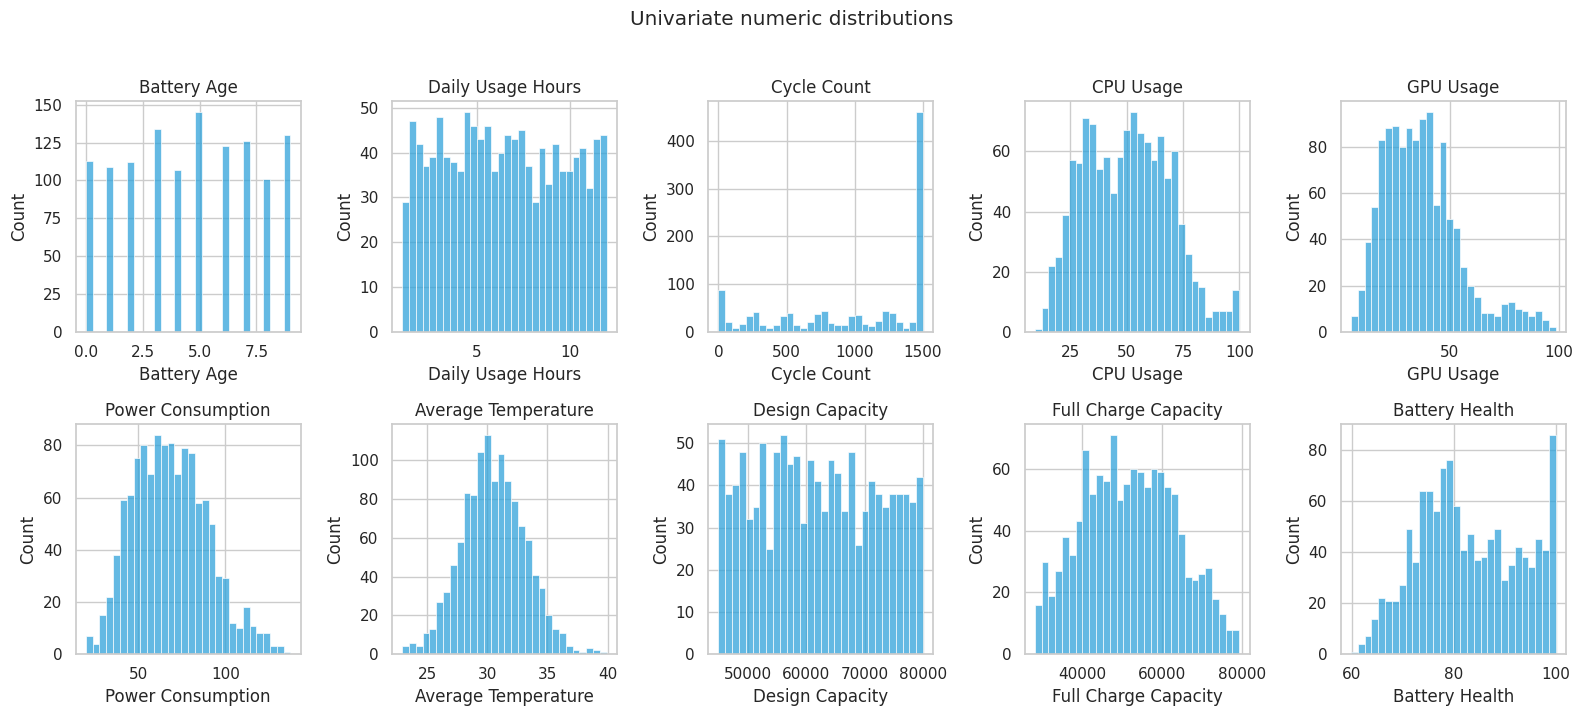

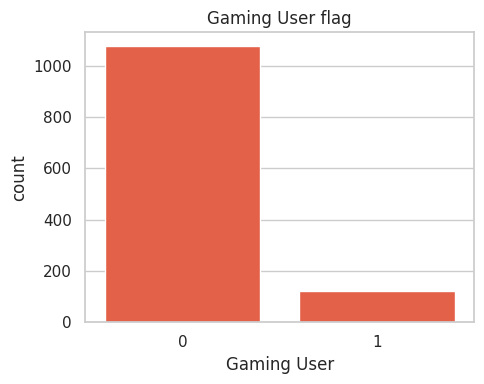

In [5]:
num_cols = [
    "Battery Age", "Daily Usage Hours", "Cycle Count", "CPU Usage", "GPU Usage",
    "Power Consumption", "Average Temperature", "Design Capacity",
    "Full Charge Capacity", "Battery Health",
]
f, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, ax=axes[i], color="#30a2da")
    axes[i].set_title(col)
plt.suptitle("Univariate numeric distributions", y=1.02)
plt.tight_layout()
plt.show()

f, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=df["Gaming User"], ax=ax, color="#fc4f30")
ax.set_title("Gaming User flag")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Age and cycle count are the classic wear clocks. Temperature and power show workload/thermal load. Health should sit left of 100% if degradation is present in the generator.


# **4. Identity Check: Health vs Capacity Ratio:** <a id="Identity"></a>


corr(Battery Health, FCC/Design*100): 0.9889
max abs difference: 4.9764


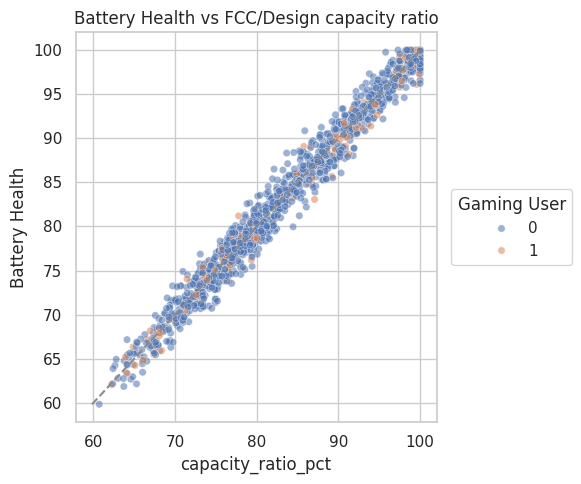

In [6]:
corr_id = df["Battery Health"].corr(df["capacity_ratio_pct"])
max_abs = (df["Battery Health"] - df["capacity_ratio_pct"]).abs().max()
print("corr(Battery Health, FCC/Design*100):", round(corr_id, 4))
print("max abs difference:", round(max_abs, 4))
assert corr_id > 0.95, "expected near-identity between health and capacity ratio"

f, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=df, x="capacity_ratio_pct", y="Battery Health",
    hue="Gaming User", alpha=0.55, s=28, ax=ax,
)
ax.plot([df["Battery Health"].min(), 100], [df["Battery Health"].min(), 100], ls="--", color="#8b8b8b")
ax.set_title("Battery Health vs FCC/Design capacity ratio")
ax.legend(title="Gaming User", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Points hugging the diagonal mean health is essentially the capacity ratio plus small noise. Including `Full Charge Capacity` when predicting health is leakage — treat FCC as an alternate label, not a driver.


# **5. Degradation Drivers:** <a id="Drivers"></a>


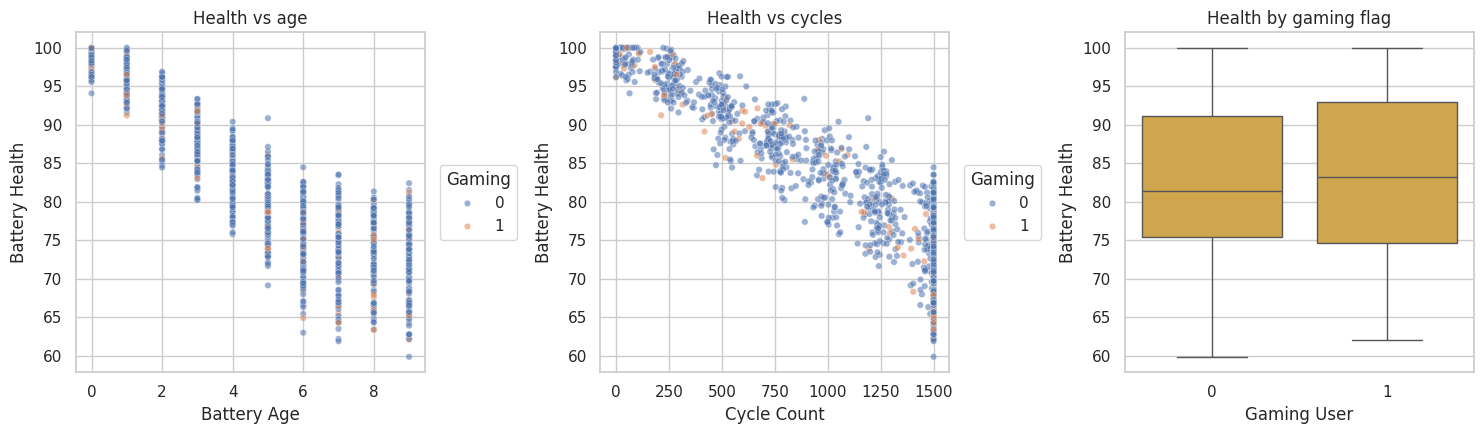

,Battery Health,Cycle Count,Average Temperature,Daily Usage Hours
Gaming User,,,,
0,82.88,1001.84,30.20,6.44
1,83.49,923.50,32.96,6.35


In [7]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.scatterplot(data=df, x="Battery Age", y="Battery Health", hue="Gaming User", ax=ax[0], alpha=0.55, s=22)
ax[0].set_title("Health vs age")
ax[0].legend(title="Gaming", bbox_to_anchor=(1.02, 0.5), loc="center left")
sns.scatterplot(data=df, x="Cycle Count", y="Battery Health", hue="Gaming User", ax=ax[1], alpha=0.55, s=22)
ax[1].set_title("Health vs cycles")
ax[1].legend(title="Gaming", bbox_to_anchor=(1.02, 0.5), loc="center left")
sns.boxplot(data=df, x="Gaming User", y="Battery Health", ax=ax[2], color="#e5ae38")
ax[2].set_title("Health by gaming flag")
plt.tight_layout()
plt.show()

display(
    df.groupby("Gaming User")[["Battery Health", "Cycle Count", "Average Temperature", "Daily Usage Hours"]]
    .mean()
    .round(2)
)


**How to Interpret:** <br>
Downward slopes vs age/cycles are the generator's wear story. Gaming boxes ask whether gamers sit at lower health after accounting for the visual overlap in scatterplots.


# **6. Usage Intensity and Thermals:** <a id="Usage"></a>


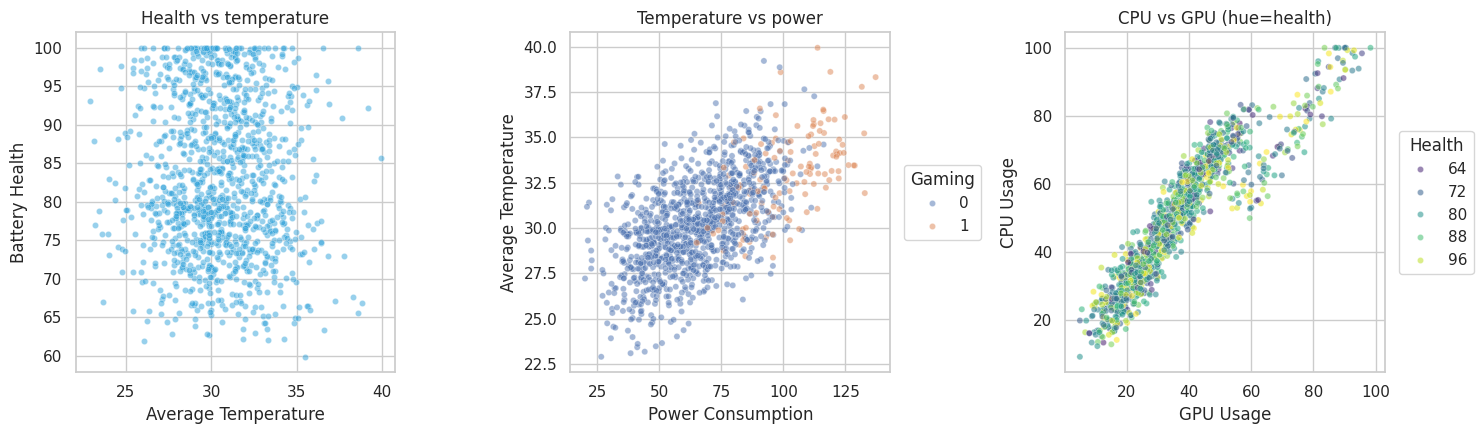

In [8]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.scatterplot(data=df, x="Average Temperature", y="Battery Health", ax=ax[0], alpha=0.5, s=20, color="#30a2da")
ax[0].set_title("Health vs temperature")
sns.scatterplot(data=df, x="Power Consumption", y="Average Temperature", hue="Gaming User", ax=ax[1], alpha=0.5, s=20)
ax[1].set_title("Temperature vs power")
ax[1].legend(title="Gaming", bbox_to_anchor=(1.02, 0.5), loc="center left")
sns.scatterplot(data=df, x="GPU Usage", y="CPU Usage", hue="Battery Health", palette="viridis", ax=ax[2], alpha=0.55, s=20)
ax[2].set_title("CPU vs GPU (hue=health)")
ax[2].legend(title="Health", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Thermals and power should move together if the generator encodes workload heat. CPU/GPU clouds colored by health show whether high utilization coincides with worse remaining capacity.


# **7. Association Without Leakage:** <a id="Association"></a>


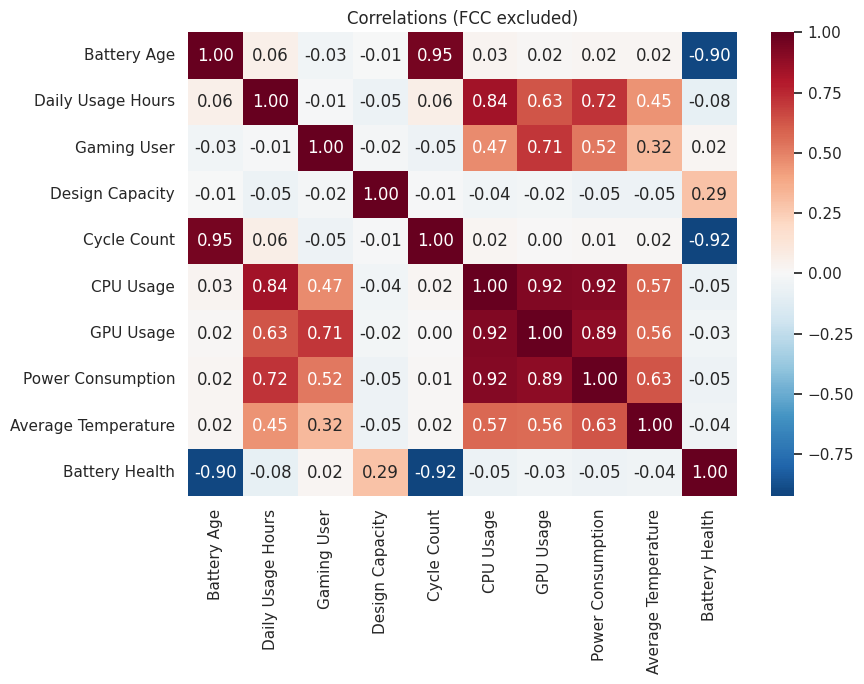

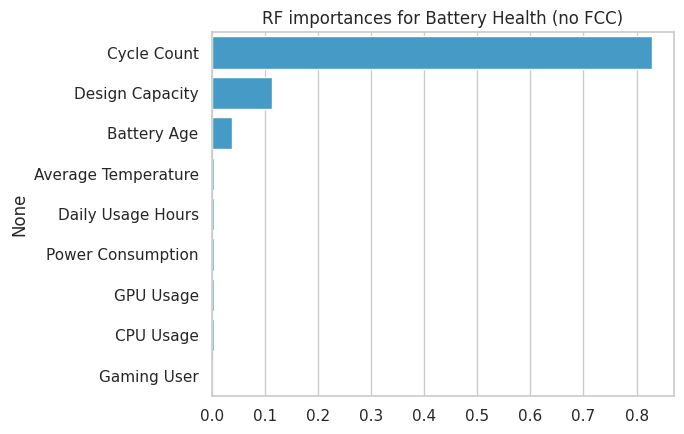

RF in-sample R^2 (no FCC): 0.992


In [9]:
# Correlation among drivers + health — exclude FCC (leakage) and the derived ratio
corr_cols = [
    "Battery Age", "Daily Usage Hours", "Gaming User", "Design Capacity", "Cycle Count",
    "CPU Usage", "GPU Usage", "Power Consumption", "Average Temperature", "Battery Health",
]
corr = df[corr_cols].corr()
f, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlations (FCC excluded)")
plt.tight_layout()
plt.show()

feature_cols = [
    "Battery Age", "Daily Usage Hours", "Gaming User", "Design Capacity", "Cycle Count",
    "CPU Usage", "GPU Usage", "Power Consumption", "Average Temperature",
]
X = df[feature_cols]
y = df["Battery Health"]
rf = RandomForestRegressor(n_estimators=300, random_state=7, n_jobs=-1, max_depth=10)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
f, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF importances for Battery Health (no FCC)")
plt.tight_layout()
plt.show()
print("RF in-sample R^2 (no FCC):", round(rf.score(X, y), 3))


**How to Interpret:** <br>
Importances rank wear and usage signals the forest used without seeing FCC. In-sample R² is exploratory only — not a held-out estimate of predictive skill.


# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic battery-health practice set where the label nearly equals the capacity ratio.

**Working takeaways:** <br>
- Never treat `Full Charge Capacity` as an innocent predictor of `Battery Health`.
- Age, cycles, temperature, and gaming are the interesting degradation axes.
- Quote nothing here as a real OEM health model.

**Open follow-ups:** <br>
- Partial dependence of temperature after controlling for age/cycles.
- Stratified gaming vs non-gaming wear curves.
